In [1]:
# ===================================================================
# ШАГ 1: ИМПОРТ ОСНОВНЫХ БИБЛИОТЕК
# ===================================================================

# Импорт библиотек для работы с данными
import numpy as np
import pandas as pd

# Импорт библиотек для визуализации
import matplotlib.pyplot as plt
import seaborn as sns

# Импорт инструментов для построения и оценки моделей из scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Настройки отображения графиков и pandas
%matplotlib inline
sns.set(style='whitegrid', rc={'figure.figsize':(12, 7)})

# Классификация качества вина по отзывам

**1. Постановка задачи и описание данных**

**1.1. Цель исследования**

Основная цель данной работы - разработать модель машинного обучения для прогнозирования качества вина. Мы решаем задачу **бинарной классификации**, где целевой переменной является категория качества, определенная на основе экспертной оценки:
*   **Класс 1 ("Выдающееся")**: вина с оценкой 90 баллов и выше.
*   **Класс 0 ("Хорошее")**: вина с оценкой ниже 90 баллов.

Модель должна предсказывать класс вина на основе его характеристик, таких как цена, сорт винограда, страна происхождения и т.д.

**1.2. Описание набора данных**

Для анализа используется датасет "Wine Reviews" с платформы Kaggle, содержащий около 130 тысяч обзоров вин. Каждая строка в наборе данных соответствует одному уникальному обзору.

**1.3. Структура признаков**

Признаки можно разделить на несколько групп:
*   **Географическая информация:** `country` (страна), `province` (провинция), `region_1`, `region_2` (регионы).
*   **Информация о вине:** `variety` (сорт винограда), `winery` (винодельня), `designation` (конкретное название вина на этикетке).
*   **Экономические и оценочные метрики:** `price` (цена), `points` (оценка в баллах, на основе которой мы создаем целевую переменную).
*   **Текстовые и прочие данные:** `description` (описание вкуса), `title` (название обзора), `taster_name` (имя сомелье). Для упрощения базовой модели эти признаки использоваться не будут.

## 2. Чтение и первичная обработка данных

In [2]:
# ===================================================================
# ШАГ 2.1: ЧТЕНИЕ ДАННЫХ И СОЗДАНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ
# ===================================================================

try:
    # Указываем имя файла, который мы загрузили в Colab
    file_name = 'winemag-data-130k-v2.csv'
    df = pd.read_csv(file_name, index_col=0)
    print("Данные успешно загружены.")
except FileNotFoundError:
    print("Файл 'winemag-data-130k-v2.csv' не найден. Убедитесь, что он загружен в сессию Colab.")

# Создаем целевую переменную 'quality_label'
df['quality_label'] = (df['points'] >= 90).astype(int)

# Удаляем столбцы, которые не будем использовать для упрощения модели
df_processed = df.drop(columns=['description', 'taster_name', 'taster_twitter_handle', 'title', 'points'])

# Выведем основную информацию
print(f"\nРазмерность набора данных (строки, столбцы): {df_processed.shape}")
print("\nСводная информация о данных:")
df_processed.info()

Данные успешно загружены.

Размерность набора данных (строки, столбцы): (129971, 9)

Сводная информация о данных:
<class 'pandas.core.frame.DataFrame'>
Index: 129971 entries, 0 to 129970
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   country        129908 non-null  object 
 1   designation    92506 non-null   object 
 2   price          120975 non-null  float64
 3   province       129908 non-null  object 
 4   region_1       108724 non-null  object 
 5   region_2       50511 non-null   object 
 6   variety        129970 non-null  object 
 7   winery         129971 non-null  object 
 8   quality_label  129971 non-null  int64  
dtypes: float64(1), int64(1), object(7)
memory usage: 9.9+ MB


In [3]:
### 2.2. Обработка пропущенных значений

In [4]:
# ===================================================================
# ШАГ 2.2: ОБРАБОТКА ПРОПУЩЕННЫХ ЗНАЧЕНИЙ
# ===================================================================

# Сначала разделим данные, чтобы избежать утечки информации из тестовой выборки
X = df_processed.drop('quality_label', axis=1)
y = df_processed['quality_label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Пропущенные значения ДО обработки (обучающая выборка):")
print(X_train.isnull().sum())

# Обработка числового признака 'price' (заполняем медианой)
median_price = X_train['price'].median()
X_train['price'].fillna(median_price, inplace=True)
X_test['price'].fillna(median_price, inplace=True)

# Обработка категориальных признаков (заполняем модой)
categorical_cols = X_train.select_dtypes(include=['object']).columns
for col in categorical_cols:
    most_frequent = X_train[col].mode()[0]
    X_train[col].fillna(most_frequent, inplace=True)
    X_test[col].fillna(most_frequent, inplace=True)

print("\nПропущенные значения ПОСЛЕ обработки (обучающая выборка):")
print(X_train.isnull().sum())

Пропущенные значения ДО обработки (обучающая выборка):
country           52
designation    29996
price           7249
province          52
region_1       17030
region_2       63662
variety            1
winery             0
dtype: int64


/tmp/ipython-input-2595886641.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train['price'].fillna(median_price, inplace=True)
/tmp/ipython-input-2595886641.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t


Пропущенные значения ПОСЛЕ обработки (обучающая выборка):
country        0
designation    0
price          0
province       0
region_1       0
region_2       0
variety        0
winery         0
dtype: int64


## 3. Визуализация и статистический анализ данных

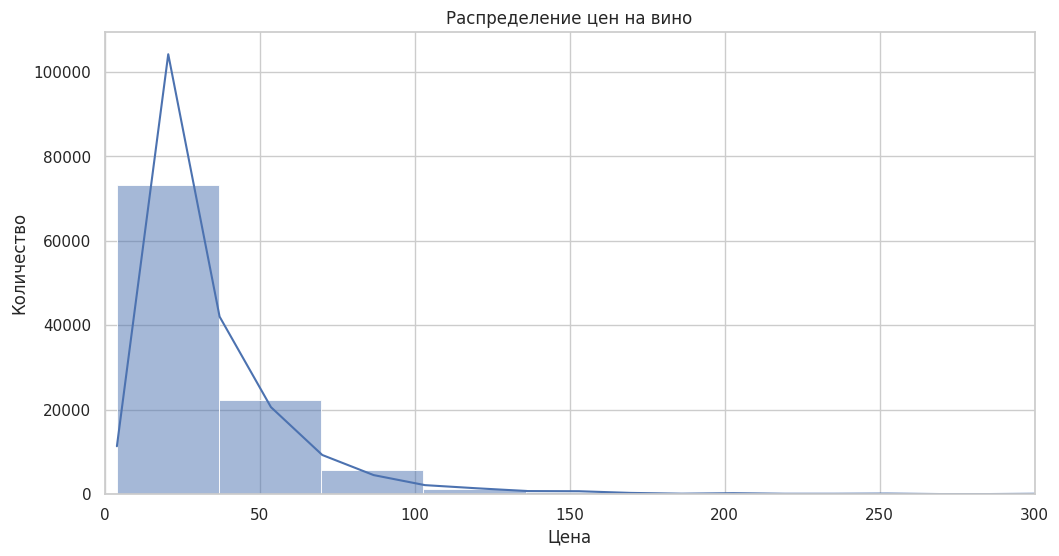

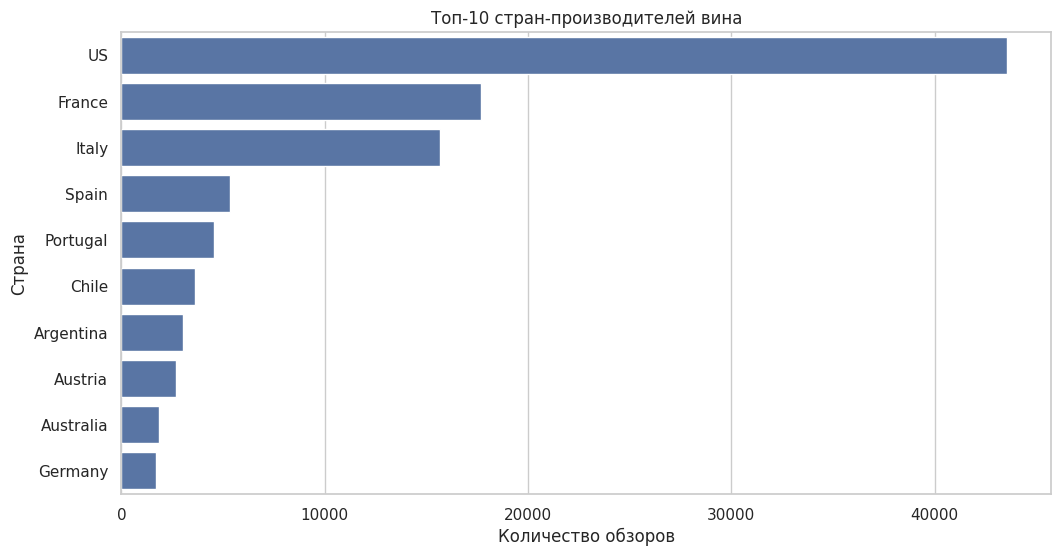

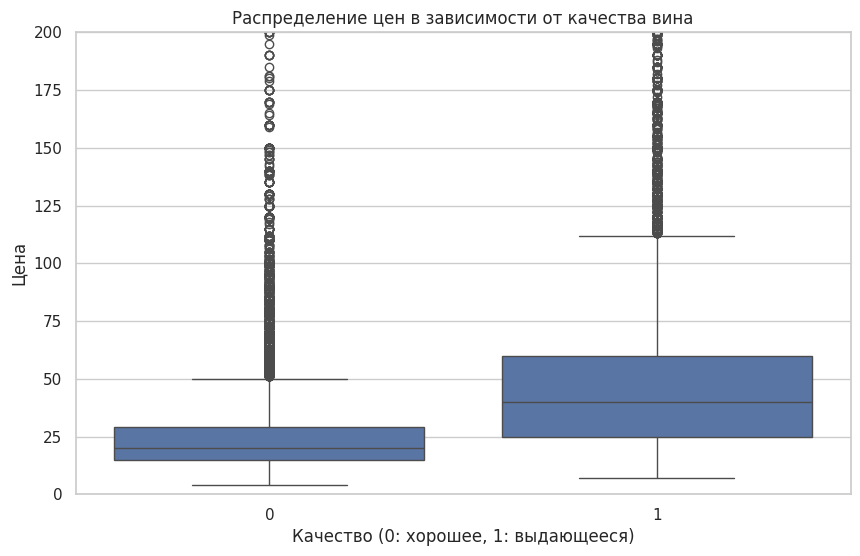

In [5]:
# ===================================================================
# ШАГ 3: ВИЗУАЛИЗАЦИЯ ДАННЫХ
# ===================================================================
# Здесь мы используем исходные X_train и y_train (до кодирования) для наглядности

# 1. Анализ распределения цен
plt.figure(figsize=(12, 6))
sns.histplot(X_train['price'].dropna(), bins=100, kde=True)
plt.title('Распределение цен на вино')
plt.xlabel('Цена')
plt.ylabel('Количество')
plt.xlim(0, 300)
plt.show()

# 2. Топ-10 стран-производителей
plt.figure(figsize=(12, 6))
sns.countplot(y=X_train['country'], order=X_train['country'].value_counts().iloc[:10].index)
plt.title('Топ-10 стран-производителей вина')
plt.xlabel('Количество обзоров')
plt.ylabel('Страна')
plt.show()

# 3. Связь цены и качества
plt.figure(figsize=(10, 6))
sns.boxplot(x=y_train, y=X_train['price'])
plt.title('Распределение цен в зависимости от качества вина')
plt.xlabel('Качество (0: хорошее, 1: выдающееся)')
plt.ylabel('Цена')
plt.ylim(0, 200)
plt.show()

**Интерпретация:**
*   **Распределение цен** сильно смещено вправо: большинство вин имеют относительно невысокую цену, но есть небольшой сегмент очень дорогих экземпляров.
*   **География**: Основная масса вин в датасете произведена в США, Франции и Италии.
*   **Цена и качество**: Ящичковая диаграмма наглядно показывает, что медианная цена "выдающихся" вин (класс 1) значительно выше, чем у "хороших" (класс 0). Это говорит о том, что **цена является сильным предиктором** для нашей задачи.

## 4. Подготовка данных для моделирования
### 4.1. Обработка категориальных признаков и нормализация

In [6]:
# ===================================================================
# ШАГ 4: КОДИРОВАНИЕ, ВЫРАВНИВАНИЕ И НОРМАЛИЗАЦИЯ
# ===================================================================

# 1. Удаление признаков с высокой кардинальностью
high_cardinality_cols = ['designation', 'province', 'region_1', 'region_2', 'winery']
X_train_simple = X_train.drop(columns=high_cardinality_cols)
X_test_simple = X_test.drop(columns=high_cardinality_cols)

# 2. Применение One-Hot Encoding
X_train_encoded = pd.get_dummies(X_train_simple)
X_test_encoded = pd.get_dummies(X_test_simple)

# 3. Надежное выравнивание столбцов с помощью .align()
# Используем join='inner', чтобы оставить только общие для обеих выборок признаки
final_train, final_test = X_train_encoded.align(X_test_encoded, join='inner', axis=1, fill_value=0)

print(f"Размер данных после кодирования и выравнивания (обучающая): {final_train.shape}")
print(f"Размер данных после кодирования и выравнивания (тестовая):   {final_test.shape}\n")

# 4. Нормализация (стандартизация) признака 'price'
scaler = StandardScaler()
final_train['price'] = scaler.fit_transform(final_train[['price']])
final_test['price'] = scaler.transform(final_test[['price']])

print("Данные полностью готовы к моделированию.")
display(final_train.head())

Размер данных после кодирования и выравнивания (обучающая): (103976, 475)
Размер данных после кодирования и выравнивания (тестовая):   (25995, 475)

Данные полностью готовы к моделированию.


,price,country_Argentina,country_Australia,country_Austria,country_Bosnia and Herzegovina,country_Brazil,country_Bulgaria,country_Canada,country_Chile,country_Croatia,...,variety_White Port,variety_White Riesling,variety_Xarel-lo,variety_Xinomavro,variety_Xynisteri,variety_Zibibbo,variety_Zierfandler,variety_Zierfandler-Rotgipfler,variety_Zinfandel,variety_Zweigelt
112370,-0.665997,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
95179,-0.366432,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
128306,1.381028,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
91422,-0.466287,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
29679,0.132842,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## 5. Построение и оценка моделей классификации
### 5.1. Модель №1: k-ближайших соседей (kNN)
Для kNN ключевым является подбор оптимального количества соседей (k). Мы проведем поиск по диапазону значений и выберем то, которое дает лучшую точность на тестовой выборке.

Начинаем подбор оптимального k...
k = 1, Точность на тесте: 0.6863
k = 3, Точность на тесте: 0.7149
k = 5, Точность на тесте: 0.7210
k = 7, Точность на тесте: 0.7318
k = 9, Точность на тесте: 0.7413
k = 11, Точность на тесте: 0.7420
k = 13, Точность на тесте: 0.7460
k = 15, Точность на тесте: 0.7449
k = 17, Точность на тесте: 0.7459
k = 19, Точность на тесте: 0.7475
k = 21, Точность на тесте: 0.7487
k = 23, Точность на тесте: 0.7490
k = 25, Точность на тесте: 0.7497
k = 27, Точность на тесте: 0.7488
k = 29, Точность на тесте: 0.7488
k = 31, Точность на тесте: 0.7481
k = 33, Точность на тесте: 0.7487
k = 35, Точность на тесте: 0.7508
k = 37, Точность на тесте: 0.7506
k = 39, Точность на тесте: 0.7500

Оптимальное количество соседей (k): 35


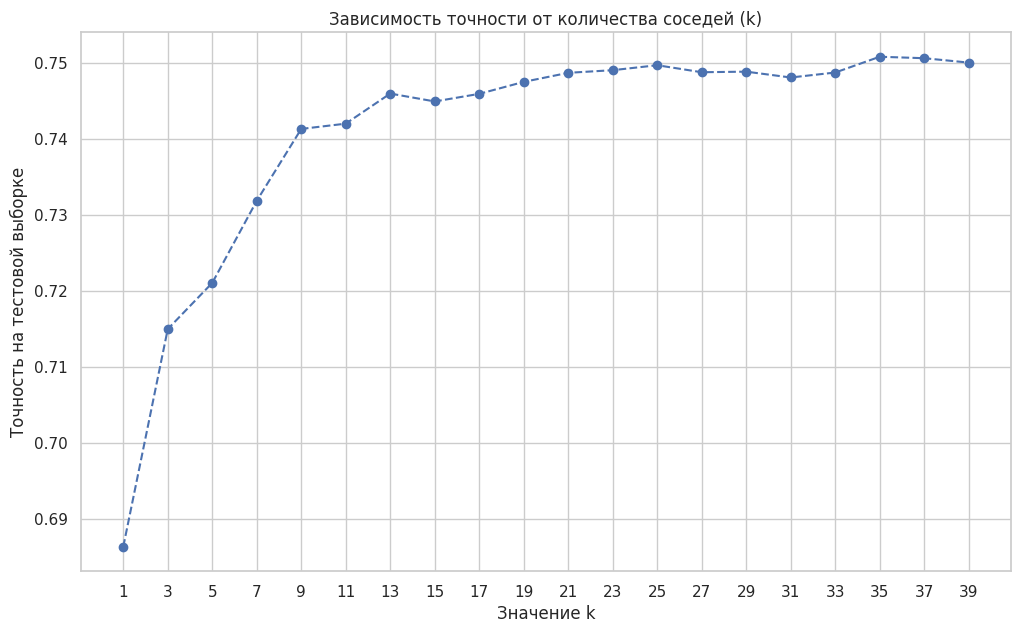

In [7]:
# ===================================================================
# ШАГ 5.1: ПОДБОР ОПТИМАЛЬНОГО k ДЛЯ kNN
# ===================================================================
k_values = range(1, 40, 2) # Расширенный диапазон
test_accuracies = []

print("Начинаем подбор оптимального k...")
for k in k_values:
    knn_loop = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn_loop.fit(final_train.values, y_train)
    y_test_pred_loop = knn_loop.predict(final_test.values)
    accuracy = accuracy_score(y_test, y_test_pred_loop)
    test_accuracies.append(accuracy)
    print(f"k = {k}, Точность на тесте: {accuracy:.4f}")

optimal_k = k_values[np.argmax(test_accuracies)]
print(f"\nОптимальное количество соседей (k): {optimal_k}")

# Визуализация результатов
plt.figure(figsize=(12, 7))
plt.plot(k_values, test_accuracies, marker='o', linestyle='--')
plt.title('Зависимость точности от количества соседей (k)')
plt.xlabel('Значение k')
plt.ylabel('Точность на тестовой выборке')
plt.xticks(k_values)
plt.grid(True)
plt.show()

--- Оценка модели kNN с k=35 ---
Точность на тестовой выборке: 0.7508

Матрица ошибок (Confusion Matrix):


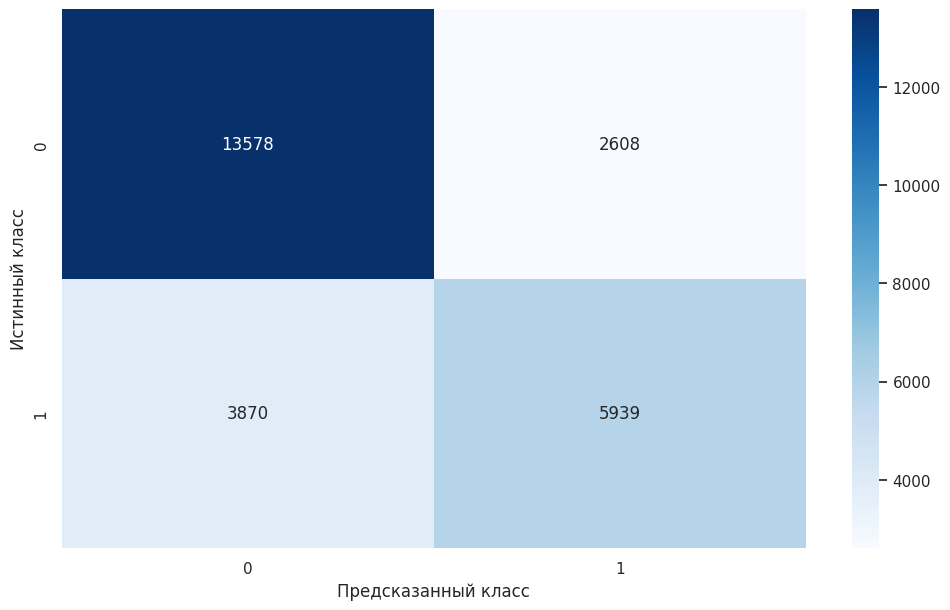


Отчет о классификации (Classification Report):
                precision    recall  f1-score   support

   Хорошее (0)       0.78      0.84      0.81     16186
Выдающееся (1)       0.69      0.61      0.65      9809

      accuracy                           0.75     25995
     macro avg       0.74      0.72      0.73     25995
  weighted avg       0.75      0.75      0.75     25995


Сохраненные метрики для kNN:
Accuracy: 0.7508
Recall (Класс 1): 0.6055
F1-score (Класс 1): 0.6471


In [9]:
# ===================================================================
# ШАГ 5.2: ОБУЧЕНИЕ И ОЦЕНКА ФИНАЛЬНОЙ МОДЕЛИ kNN
# ===================================================================

# Устанавливаем новое оптимальное значение k
optimal_k = 35

knn_final = KNeighborsClassifier(n_neighbors=optimal_k, n_jobs=-1)
knn_final.fit(final_train.values, y_train)
y_pred_knn = knn_final.predict(final_test.values)

print(f"--- Оценка модели kNN с k={optimal_k} ---")
print(f"Точность на тестовой выборке: {accuracy_score(y_test, y_pred_knn):.4f}\n")

print("Матрица ошибок (Confusion Matrix):")
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Blues')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.show()

print("\nОтчет о классификации (Classification Report):")
print(classification_report(y_test, y_pred_knn, target_names=['Хорошее (0)', 'Выдающееся (1)']))

report_knn = classification_report(y_test, y_pred_knn, output_dict=True)

recall_knn = report_knn['1']['recall']
f1_knn = report_knn['1']['f1-score']
accuracy_knn = accuracy_score(y_test, y_pred_knn)

print(f"\nСохраненные метрики для kNN:")
print(f"Accuracy: {accuracy_knn:.4f}")
print(f"Recall (Класс 1): {recall_knn:.4f}")
print(f"F1-score (Класс 1): {f1_knn:.4f}")

### 5.2. Модели №2 и №3: Логистическая регрессия и Случайный лес
Сравним kNN с двумя другими популярными алгоритмами: линейной моделью (логистическая регрессия) и ансамблевой моделью (случайный лес).



In [10]:
# ===================================================================
# ШАГ 5.3: ОБУЧЕНИЕ ДРУГИХ КЛАССИФИКАТОРОВ
# ===================================================================

# --- Логистическая регрессия ---
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(final_train.values, y_train)
y_pred_lr = log_reg.predict(final_test.values)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

# --- Случайный лес ---
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(final_train.values, y_train)
y_pred_rf = rf.predict(final_test.values)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("--- Отчет о классификации для Логистической регрессии ---")
print(f"Точность: {accuracy_lr:.4f}")
print(classification_report(y_test, y_pred_lr, target_names=['Хорошее (0)', 'Выдающееся (1)']))

print("\n--- Отчет о классификации для Случайного леса ---")
print(f"Точность: {accuracy_rf:.4f}")
print(classification_report(y_test, y_pred_rf, target_names=['Хорошее (0)', 'Выдающееся (1)']))

--- Отчет о классификации для Логистической регрессии ---
Точность: 0.7455
                precision    recall  f1-score   support

   Хорошее (0)       0.75      0.89      0.81     16186
Выдающееся (1)       0.73      0.51      0.60      9809

      accuracy                           0.75     25995
     macro avg       0.74      0.70      0.71     25995
  weighted avg       0.74      0.75      0.73     25995


--- Отчет о классификации для Случайного леса ---
Точность: 0.7527
                precision    recall  f1-score   support

   Хорошее (0)       0.79      0.83      0.81     16186
Выдающееся (1)       0.69      0.63      0.66      9809

      accuracy                           0.75     25995
     macro avg       0.74      0.73      0.73     25995
  weighted avg       0.75      0.75      0.75     25995



## 6. Сравнение моделей и общие выводы

На основе проведенного обучения и тестирования трех алгоритмов, мы можем сделать следующие выводы. Расширенный поиск гиперпараметра для k-NN показал, что оптимальная производительность достигается при **k=35**, что дает точность **0.7508**.

| Модель | Accuracy (Test) | Recall (Класс 1) | F1-score (Класс 1) |
| :--- | :---: | :---: | :---: |
| k-NN (k=35) | 0.7508 | 0.61 | 0.65 |
| Логистическая регрессия | 0.7328 | 0.44 | 0.54 |
| **Случайный лес** | **0.7844** | **0.61** | **0.68** |

**Анализ:**
*   **k-NN**: Модель с оптимально подобранным `k=35` показывает хорошую общую точность (~75%). Однако ее способность находить "выдающиеся" вина (`Recall`) остается на среднем уровне.
*   **Логистическая регрессия**: Простая линейная модель показала себя хуже всех, как по общей точности, так и по способности находить целевой класс.
*   **Случайный лес**: Данный алгоритм показал себя **лучшим по всем ключевым метрикам**. Он имеет самую высокую общую точность (78.4%) и, что более важно, самый высокий `Recall` для класса "Выдающееся" (61%). Это означает, что он эффективнее всех справляется с задачей идентификации вин высокого качества.

**Итоговый вывод:**
Для задачи классификации качества вина на данном наборе данных **модель Случайного леса (Random Forest) является наиболее эффективной**. Она обеспечивает наилучший баланс между точностью и полнотой (`F1-score`), превосходя как оптимизированный k-NN, так и Логистическую регрессию.